# Trabajo práctico No 6: Rotación diferencial galáctica

### 2. A partir del catálogo de cúmulos abiertos de [Dias et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021MNRAS.504..356D/) (disponible [aquí](https://vizier.cds.unistra.fr/viz-bin/VizieR-3?-source=J/MNRAS/504/356)) obtener las coordenadas galácticas ($l,b$), la distancia ($d$) y la velocidad radial ($v_r$) con sus errores, para todos los cúmulos que cumplan las siguientes condiciones: 
* #### que tengan distancia conocida (Dist !=null);
* #### que su número estimado de miembros  sea mayor que 10 (N $> 10$);
* #### que su $v_r$ sea también conocida (RV !=null) y
* #### que el número de medidas utilizadas para determinar $v_r$ sea mayor que 1 (NRV~$>$~1).

#### Con esos datos, realice un gráfico ($l,v_r$). Describa el gráfico e interprételo en el marco del modelo de rotación galáctica estudiado en la teoría. 

#### Luego, suponiendo que la velocidad radial puede expresarse mediante la ecuación del ejercicio 1. estime el valor de la constante de Oort $A$ (en km s$^{-1}$ kpc$^{-1}$). Presente un gráfico con los datos observados, y el ajuste obtenido. Analice y comente los resultados.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
plt.style.use('sisest.mplstyle')

In [2]:
dias = pd.read_csv('Dias_2021.csv', sep=';', comment='#')
dias.head()

,_Glon,_Glat,Cluster,RV,e_RV,Dist,e_Dist
0,155.707379,-17.743708,ASCC_10,-10.870,5.243,643,30
1,68.031685,11.591740,ASCC_101,-19.198,2.884,397,1
2,62.858154,1.999050,ASCC_105,-14.302,4.090,545,8
3,150.545345,-9.195826,ASCC_11,-14.242,0.233,849,20
4,70.442308,1.367418,ASCC_110,-1.178,0.856,1583,143


Text(0, 0.5, 'Velocidad Radial $v_r~[km/seg]$')

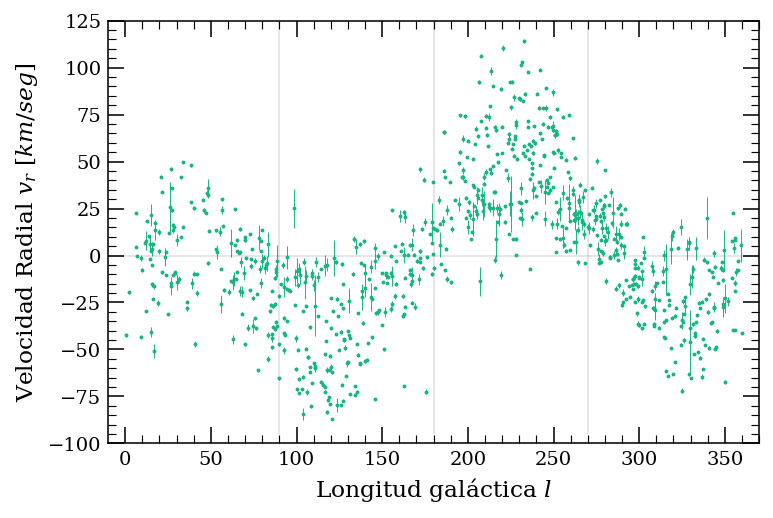

In [3]:
fig = plt.figure(figsize=(6,4), dpi=140)

plt.errorbar(dias._Glon,
            dias.RV,
            yerr=dias.e_RV,
            fmt='.', c='#17B583', markersize=2, elinewidth=.5)
plt.hlines(0,-10,370, colors='k',lw=0.1)
plt.vlines(90,-95,125, colors='k',lw=0.1)
plt.vlines(180,-95,125, colors='k',lw=0.1)
plt.vlines(270,-95,125, colors='k',lw=0.1)
# Para distintas distancias vamos a tener curvas de distinta amplitud. Por esto se debe la dispersión en la curva, sumado a un factor relacionado a la lejanía del cúmulo al plano (cos²b).
# Se podría intentar trazar una curva sobre el gráfico o poner restricciones en la distancia
plt.xlim(-10,370)
plt.ylim(-100,125)
plt.xlabel('Longitud galáctica $l$')
plt.ylabel('Velocidad Radial $v_r~[km/seg]$')

In [4]:
dias['x'] = (dias.Dist/1000.) * np.sin(2*dias._Glon*np.pi/180.) * np.cos(dias._Glat*np.pi/180.)**2
dias.head()

,_Glon,_Glat,Cluster,RV,e_RV,Dist,e_Dist,x
0,155.707379,-17.743708,ASCC_10,-10.870,5.243,643,30,-0.437425
1,68.031685,11.591740,ASCC_101,-19.198,2.884,397,1,0.264341
2,62.858154,1.999050,ASCC_105,-14.302,4.090,545,8,0.441957
3,150.545345,-9.195826,ASCC_11,-14.242,0.233,849,20,-0.708474
4,70.442308,1.367418,ASCC_110,-1.178,0.856,1583,143,0.998121


In [5]:
# Realizamos un ajuste para calcular la constante de Oort
def f(x,A):
    return A*x

coef, cov = curve_fit(f, dias.x[dias.Dist<1000.], dias.RV[dias.Dist<1000.])
A = coef[0]
Aerr = np.sqrt(cov[0][0])

A, Aerr

(15.185661115373737, 2.606486406702632)

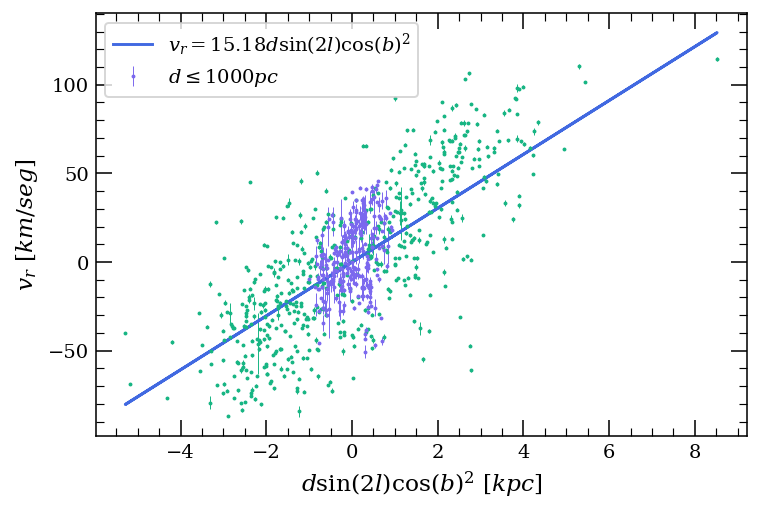

In [6]:
fig = plt.figure(figsize=(6,4), dpi=140)

plt.errorbar(dias.x[dias.Dist>=1000], 
             dias.RV[dias.Dist>=1000], 
             yerr=dias.e_RV[dias.Dist>=1000], 
             fmt='.', markersize=2, elinewidth=.5, c='#17B583') #La dispersión vertical es originada por la velocidad peculiar

plt.errorbar(dias.x[dias.Dist<1000.],
            dias.RV[dias.Dist<1000.],
            yerr=dias.e_RV[dias.Dist<1000.],
            fmt='.', markersize=2, elinewidth=.5, c='mediumslateblue', label='$d\leq 1000pc$')

plt.plot(dias.x, f(dias.x,A), c='royalblue', label='$v_r=15.18d\sin(2l)\cos(b)^2$')

plt.ylabel('$v_r~[km/seg]$')
plt.xlabel('$d\sin(2l)\cos(b)^2~[kpc]$')
plt.legend()
plt.show()

#### 3. La siguiente expresión, que proviene de un ajuste sobre datos de paralajes trigonométricas y movimientos propios de masers asociados con estrellas jovenes de alta masa, presentada por Reid et al. (2014), describe el comportamiento medio de la curva de rotación galáctica (válida para 5 < R < 16 kpc):
#### $\Theta (R) = a_0 + a_1R$
#### donde R se expresa en kpc, $a_0$ = 241.67 km s $^{-1}$ y $a_1$ = −0.2 km s $^{-1}$ kpc $^{-1}$. En el mismo ajuste dichos autores obtuvieron $R_0$ = 8.34 $\pm$ 0.16 kpc y $\Theta_0$ = 240 $\pm$ 8 km s $^{-1}$. Con esta expresión construya y describa las curvas de velocidad radial en función de la distancia al sol ($d$), para valores de longitud galáctica $l$ iguales a 60°, 75°, 90°y 120°. Analice e interprete las curvas obtenidas.

Para obtener $v_r$ en función de $d$ podemos usar esta ecuación de la teoría, que es válida siempre para órbitas circulares:

$v_r = [\Theta(R)\frac{R_0}{R} - \Theta_0]  \sin(l)$

donde tenemos $R$ usando el teorema del coseno (ver teoría) y los datos $d$, $l$ y $R_0$

$R = \sqrt{R_0^2 + d^2 - 2 R_0 d \cos(l)}$


In [7]:
# Velocidad de rotación galáctica (Reid)
def theta(R):
    x = 241.67 - 0.2 * R #[km/s]
    return x

# Radio galactocéntrico (t del coseno)
def R(d, l):
    x = np.sqrt(8.34**2 + d**2 - 2*8.34*d*np.cos(l*np.pi/180.))
    return x

#Velocidad radial (teoría)
def vr(R, l):
    x = (theta(R) * 8.34/R - 240)*np.sin(l*np.pi/180.)
    return x

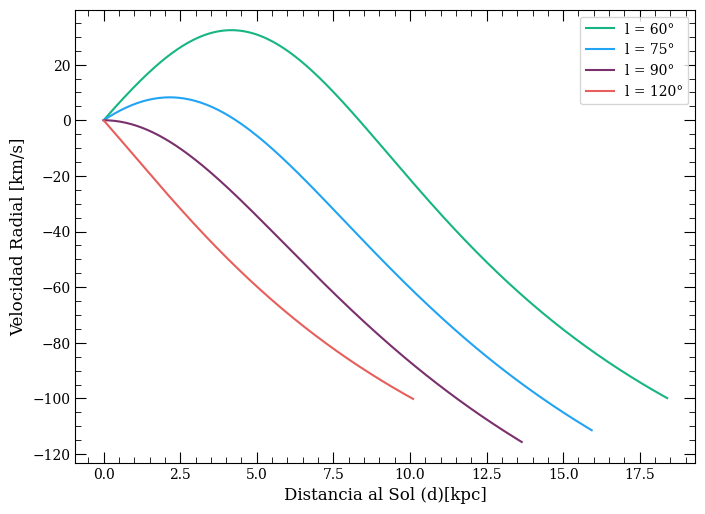

In [12]:
# Arreglo de distancia al Sol (ds)
ds = np.linspace(0,30,500)

# Arreglo de longitudes galácticas
ls = np.array([60,75,90,120])

# Diccionario con colores para graficar
colores={ls[0]: '#17B583', ls[1]: '#20A4F3', ls[2]: '#7A306C', ls[3]: '#E65F5C'}

# Graficamos, imponiendo la condición dada para la expresión de Reid+2014

fig = plt.figure(figsize = (8,6)) # , facecolor='k', dpi=160)

for l in ls:
    Rs = R(ds, l)                                      # radios galactocéntricos
    vrs = vr(Rs,l)                                     # velocidades radiales para esos radios
    plt.plot(ds[(Rs>5)&(Rs<16)],vrs[(Rs>5)&(Rs<16)],   # definimos las variables que ponemos en cada eje, imponiendo las condiciones 
             label='l = '+str(l)+'°',                  # etiquetas
             c=colores[l])                             # colores

plt.xlabel('Distancia al Sol (d)[kpc]')
plt.ylabel('Velocidad Radial [km/s]')
plt.legend()
plt.show()

In [18]:
print('G=',6.67384*10**(-11)*2*10**(30)/(3.0857*10**(19)) )
print('Mg=',((6.7885*10**(-14))**2*8.5)/(6.67384*10**(-11)*2*10**(30)/(3.0857*10**(19))) )
print('Mg=',(9.2571*10**(-14))**2*16/(6.67384*10**(-11)*2*10**(30)/(3.0857*10**(19))) )
print('Mg=',(7.7142*10**(-14))**2*30/(6.67384*10**(-11)*2*10**(30)/(3.0857*10**(19))) )

G= 4.325657063227145
Mg= 9.055542739506136e-27
Mg= 3.1696974275096434e-26
Mg= 4.127156691122681e-26
